# 02. Data Preprocessing Pipeline
**Driver Drowsiness Detection System**  
Standardizing raw eye images into normalized 80 × 80 single-channel tensors for deep learning.

---

### Pipeline Workflow:
1. **Import Libraries** - Load foundational tools (`numpy`, `pandas`, `matplotlib`, `PIL`, `IPython.display`)
2. **Load train/validation/test data** - Map subject-independent partitions to avoid data leakage
3. **Load an image** - Inspect a sample raw image and its properties
4. **Resize images → 80 × 80** - Standardize dimensions to median crop resolution
5. **Convert grayscale** - Ensure single-channel intensity (`L` mode)
6. **Normalize pixel values → 0–1** - Scale values to `[0.0, 1.0]` for model stability
7. **Prepare X and y** - Batch-process train, validation, and test datasets
8. **Check shapes** - Verify tensor dimensions and class distribution
9. **Visualize preprocessed images** - Inspect preprocessed 80 × 80 inputs with labels
10. **Save preprocessed data** - Export compressed `.npz` files for instant model training

### 1. Import Libraries
Import all necessary libraries for file traversal, image manipulation, array operations, and visualization.

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import numpy as np
import pandas as pd

### 2. Load Train / Validation / Test Data
Read the dataset folder, extract file metadata from image names, and apply the **Subject-Independent Partitioning** from `01_dataset_analysis.ipynb`.  
*This guarantees that subjects in the test set were never seen during training.*

In [2]:
df = pd.read_csv("../dataset/mrl_dataset_info.csv")

train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]
test_df = df[df["split"] == "test"]

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 59574
Validation: 13015
Test: 12309


### 3. Load an Image
Inspect a single raw sample from the training set to observe its native size, format, and color mode before preprocessing.

Sample Path:   ../dataset/mrlEyes_2018_01\s0001\s0001_00001_0_0_0_0_0_01.png
Original Size: (86, 86) (Width x Height)
Color Mode:    L
Label:         Closed Eye (0)


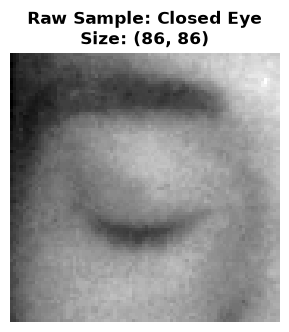

In [3]:
# Select a sample image
sample_row = train_df.iloc[0]
sample_path = sample_row["file_path"]
sample_label = "Open Eye" if sample_row["eye_state"] == 1 else "Closed Eye"

# Load image using PIL
sample_img = Image.open(sample_path)

print(f"Sample Path:   {sample_path}")
print(f"Original Size: {sample_img.size} (Width x Height)")
print(f"Color Mode:    {sample_img.mode}")
print(f"Label:         {sample_label} ({sample_row['eye_state']})")

# Visualize the original image
plt.figure(figsize=(3.5, 3.5))
plt.imshow(sample_img, cmap='gray')
plt.title(f"Raw Sample: {sample_label}\nSize: {sample_img.size}", fontweight='bold')
plt.axis('off')
plt.show()

### 4. Resize Images → 80 × 80
Raw images in the dataset have varying crops (from ~30px to over ~120px).  
We standardize all images to **80 × 80**, matching the dataset median size while preserving critical eyelid and pupil contours.

Original size: (86, 86)
Resized size: (80, 80)


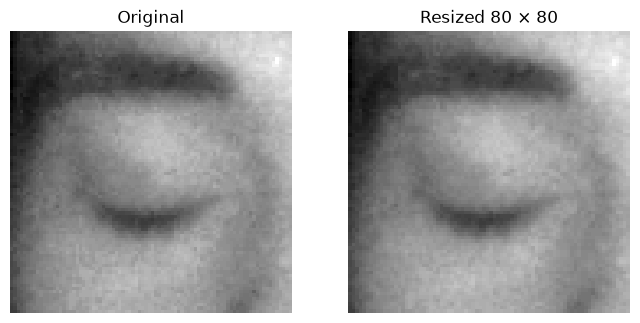

In [4]:
TARGET_SIZE = (80, 80)

resized_img = sample_img.resize(TARGET_SIZE)

print("Original size:", sample_img.size)
print("Resized size:", resized_img.size)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_img, cmap="gray")
plt.title("Resized 80 × 80")
plt.axis("off")

plt.show()

### 5. Convert Grayscale
Convert images explicitly to single-channel 8-bit grayscale (`L` mode in PIL).  
This avoids unnecessary 3-channel RGB computation and focuses the network on shape and intensity contrasts.

Image mode: L
Image size: (80, 80)


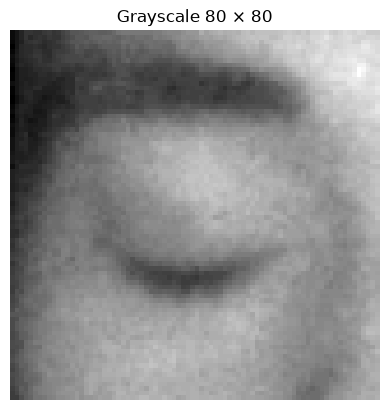

In [5]:
grayscale_img = resized_img.convert("L")

print("Image mode:", grayscale_img.mode)
print("Image size:", grayscale_img.size)

plt.imshow(grayscale_img, cmap="gray")
plt.title("Grayscale 80 × 80")
plt.axis("off")
plt.show()

### 6. Normalize Pixel Values → 0–1
Transform raw pixel intensities from integer range `[0, 255]` to floating point `[0.0, 1.0]` by dividing by `255.0`.  
*Normalization stabilizes gradient descent and speeds up training.*

Raw Pixels:        Min = 35.0, Max = 103.0, Type = float32
Normalized Pixels: Min = 0.1373, Max = 0.4039, Type = float32


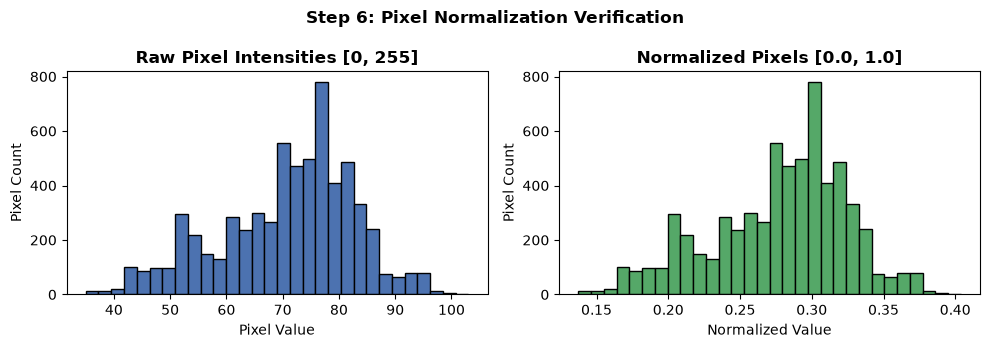

In [6]:
# Convert image to numpy float32 array
raw_pixels = np.array(grayscale_img, dtype=np.float32)

print(f"Raw Pixels:        Min = {raw_pixels.min():.1f}, Max = {raw_pixels.max():.1f}, Type = {raw_pixels.dtype}")

# Normalize to 0.0 - 1.0
normalized_pixels = raw_pixels / 255.0

print(f"Normalized Pixels: Min = {normalized_pixels.min():.4f}, Max = {normalized_pixels.max():.4f}, Type = {normalized_pixels.dtype}")

# Visualizing the distribution of pixel values
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(raw_pixels.ravel(), bins=30, color='#4C72B0', edgecolor='black')
axes[0].set_title("Raw Pixel Intensities [0, 255]", fontweight='bold')
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Pixel Count")

axes[1].hist(normalized_pixels.ravel(), bins=30, color='#55A868', edgecolor='black')
axes[1].set_title("Normalized Pixels [0.0, 1.0]", fontweight='bold')
axes[1].set_xlabel("Normalized Value")
axes[1].set_ylabel("Pixel Count")

plt.suptitle("Step 6: Pixel Normalization Verification", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Prepare X and y
Now, bundle Steps 4, 5, and 6 into a clean, reusable helper function `preprocess_dataset()` and generate the final feature matrices `X` and label vectors `y` for all splits.  
Each image tensor will have the shape **(80, 80, 1)**.

In [7]:
def preprocess_dataset(data):
    X = []
    y = []

    for _, row in data.iterrows():
        image = Image.open(row["file_path"]).convert("L")
        image = image.resize((80, 80))

        image = np.array(image, dtype=np.float32) / 255.0
        image = np.expand_dims(image, axis=-1)

        X.append(image)
        y.append(row["eye_state"])

    X = np.array(X)
    y = np.array(y)

    return X, y


X_train, y_train = preprocess_dataset(train_df)
X_val, y_val = preprocess_dataset(val_df)
X_test, y_test = preprocess_dataset(test_df)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (59574, 80, 80, 1) (59574,)
Validation: (13015, 80, 80, 1) (13015,)
Test: (12309, 80, 80, 1) (12309,)


### 8. Check Shapes
Validate the resulting array dimensions, memory types, and class balance across all splits.

In [9]:
print("Train:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest:")
print("X:", X_test.shape)
print("y:", y_test.shape)

print("\nPixel range:", X_train.min(), "to", X_train.max())
print("Data type:", X_train.dtype)

Train:
X: (59574, 80, 80, 1)
y: (59574,)

Validation:
X: (13015, 80, 80, 1)
y: (13015,)

Test:
X: (12309, 80, 80, 1)
y: (12309,)

Pixel range: 0.0 to 1.0
Data type: float32


### 9. Visualize Preprocessed Images
Inspect a grid of preprocessed 80 × 80 images from the training set, confirming proper grayscale conversion, contrast, and label alignment.

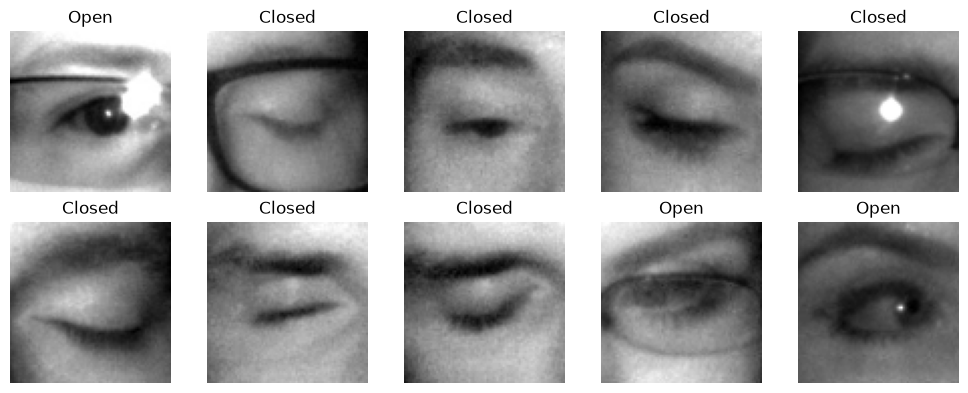

In [13]:
plt.figure(figsize=(10, 4))

indices = np.random.choice(len(X_train), 10, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[idx].squeeze(), cmap="gray")

    if y_train[idx] == 1:
        plt.title("Open")
    else:
        plt.title("Closed")

    plt.axis("off")

plt.tight_layout()
plt.show()

### 10. Save Preprocessed Data
Export all preprocessed arrays into compressed `.npz` format inside `dataset/preprocessed/`.  
*This allows `03_model_training.ipynb` to load the dataset in seconds without re-parsing 84,000+ image files!*

In [ ]:
save_path = "../dataset/preprocessed_data.npz"

np.savez_compressed(
    save_path,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

print("Preprocessed data saved successfully!")
print("File:", save_path)

Preprocessed data saved successfully!
File: ../dataset/preprocessed_data.npz


: 